# Unified Model Comparison: From Features to Mechanism

Systematic model comparison starting from simple feature models and building toward the mechanistically grounded unified model.

**Levels:**
- 0: Effort only
- 1: + additive threat
- 2: + threat × distance interaction
- 3: Survival function structure (no α)
- 4a: Unified — α in survival only
- 4b: Unified — α in effort AND survival
- Kernel comparison: exponential vs hyperbolic escape function

**Key question at each step:** Does the added complexity improve fit enough to justify it?

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.special import expit
from scipy import stats

import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO, Predictive
from numpyro.infer.autoguide import AutoNormal
from numpyro.optim import Adam
from jax import random

numpyro.set_platform('cpu')

ROOT = Path('../../')
RESULTS = ROOT / 'results'
STAT_DIR = RESULTS / 'stats'
FIG_DIR = RESULTS / 'figs'

import matplotlib.pyplot as plt
print('Setup complete')

/opt/anaconda3/envs/effort_foraging_threat/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup complete


## 1. Load data

In [2]:
behavior = pd.read_csv(ROOT / 'data/exploratory_350/processed/stage5_filtered_data_20260317_094210/behavior.csv')
vigor_params = pd.read_csv(STAT_DIR / 'vigor_hbm_posteriors.csv')

df = behavior.merge(vigor_params[['subj', 'alpha_bayes']], on='subj')

subj_ids = sorted(df['subj'].unique())
subj_to_idx = {s: i for i, s in enumerate(subj_ids)}
n_subj = len(subj_ids)

# JAX arrays
si = jnp.array(df['subj'].map(subj_to_idx).values)  # subject index
T = jnp.array(df['threat'].values, dtype=jnp.float32)
eH = jnp.array(df['effort_H'].values, dtype=jnp.float32)
eL = jnp.array(df['effort_L'].values, dtype=jnp.float32)
dH = jnp.array(df['distance_H'].values, dtype=jnp.float32)
dL = jnp.array(df['distance_L'].values, dtype=jnp.float32)
ch = jnp.array(df['choice'].values, dtype=jnp.float32)
alpha = jnp.array(df['alpha_bayes'].values, dtype=jnp.float32)

# Derived: delta features for feature-based models
dR = jnp.float32(5.0 - 1.0)  # R_H - R_L, constant
dE = eH - eL
dD = dH - dL

R_H = 5.0; R_L = 1.0

print(f'N = {n_subj} subjects, {len(df)} trials')
print(f'Effort L always = {df["effort_L"].unique()}')
print(f'Distance L always = {df["distance_L"].unique()}')

N = 293 subjects, 13185 trials
Effort L always = [0.4]
Distance L always = [1]


## 2. Define models

All models use hierarchical priors (log-normal for positive params, normal for unconstrained).

In [4]:
# ================================================================
# LEVEL 0: Effort only
# P(high) = sigmoid(tau * [R_H*exp(-k*E_H) - R_L*exp(-k*E_L)])
# ================================================================
def level_0(si, T, eH, eL, dH, dL, alpha, ch=None):
    tau = numpyro.sample('tau', dist.LogNormal(0, 1))
    mu_logk = numpyro.sample('mu_logk', dist.Normal(0, 1))
    sd_logk = numpyro.sample('sd_logk', dist.HalfNormal(1))
    with numpyro.plate('subj', n_subj):
        logk = numpyro.sample('logk', dist.Normal(mu_logk, sd_logk))
    k = jnp.exp(logk[si])
    SVH = R_H * jnp.exp(-k * eH)
    SVL = R_L * jnp.exp(-k * eL)
    numpyro.sample('ch', dist.Bernoulli(logits=tau*(SVH-SVL)), obs=ch)

# ================================================================
# LEVEL 1: + additive threat
# SV = R*exp(-k*E) - beta*T
# ================================================================
def level_1(si, T, eH, eL, dH, dL, alpha, ch=None):
    tau = numpyro.sample('tau', dist.LogNormal(0, 1))
    mu_logk = numpyro.sample('mu_logk', dist.Normal(0, 1))
    sd_logk = numpyro.sample('sd_logk', dist.HalfNormal(1))
    mu_logb = numpyro.sample('mu_logb', dist.Normal(0, 1))
    sd_logb = numpyro.sample('sd_logb', dist.HalfNormal(1))
    with numpyro.plate('subj', n_subj):
        logk = numpyro.sample('logk', dist.Normal(mu_logk, sd_logk))
        logb = numpyro.sample('logb', dist.Normal(mu_logb, sd_logb))
    k = jnp.exp(logk[si]); beta = jnp.exp(logb[si])
    # Threat penalty proportional to T (same for both options on same trial,
    # but high-effort cookie is farther so we scale by distance)
    SVH = R_H * jnp.exp(-k * eH) - beta * T * dH
    SVL = R_L * jnp.exp(-k * eL) - beta * T * dL
    numpyro.sample('ch', dist.Bernoulli(logits=tau*(SVH-SVL)), obs=ch)

# ================================================================
# LEVEL 2: + threat x distance interaction (feature-based)
# SV = R*exp(-k*E) - beta*T*D - gamma*T*D^2
# ================================================================
def level_2(si, T, eH, eL, dH, dL, alpha, ch=None):
    tau = numpyro.sample('tau', dist.LogNormal(0, 1))
    mu_logk = numpyro.sample('mu_logk', dist.Normal(0, 1))
    sd_logk = numpyro.sample('sd_logk', dist.HalfNormal(1))
    mu_logb = numpyro.sample('mu_logb', dist.Normal(0, 1))
    sd_logb = numpyro.sample('sd_logb', dist.HalfNormal(1))
    gamma = numpyro.sample('gamma', dist.Normal(0, 1))  # pop-level nonlinearity
    with numpyro.plate('subj', n_subj):
        logk = numpyro.sample('logk', dist.Normal(mu_logk, sd_logk))
        logb = numpyro.sample('logb', dist.Normal(mu_logb, sd_logb))
    k = jnp.exp(logk[si]); beta = jnp.exp(logb[si])
    threat_cost_H = beta * T * dH + gamma * T * dH**2
    threat_cost_L = beta * T * dL + gamma * T * dL**2
    SVH = R_H * jnp.exp(-k * eH) - threat_cost_H
    SVL = R_L * jnp.exp(-k * eL) - threat_cost_L
    numpyro.sample('ch', dist.Bernoulli(logits=tau*(SVH-SVL)), obs=ch)

# ================================================================
# LEVEL 3: Survival function (no alpha)
# S = (1-T) + T * exp(-lam*D)
# SV = R*exp(-k*E)*S - beta*(1-S)
# ================================================================
def level_3(si, T, eH, eL, dH, dL, alpha, ch=None):
    tau = numpyro.sample('tau', dist.LogNormal(0, 1))
    lam = numpyro.sample('lam', dist.LogNormal(0, 1))
    mu_logk = numpyro.sample('mu_logk', dist.Normal(0, 1))
    sd_logk = numpyro.sample('sd_logk', dist.HalfNormal(1))
    mu_logb = numpyro.sample('mu_logb', dist.Normal(0, 1))
    sd_logb = numpyro.sample('sd_logb', dist.HalfNormal(1))
    with numpyro.plate('subj', n_subj):
        logk = numpyro.sample('logk', dist.Normal(mu_logk, sd_logk))
        logb = numpyro.sample('logb', dist.Normal(mu_logb, sd_logb))
    k = jnp.exp(logk[si]); beta = jnp.exp(logb[si])
    # Mechanistic S: P(survive) = P(no attack) + P(attack)*P(escape|attack)
    f_H = jnp.exp(-lam * dH)  # escape prob given attack
    f_L = jnp.exp(-lam * dL)
    SH = (1 - T) + T * f_H
    SL = (1 - T) + T * f_L
    SVH = R_H * jnp.exp(-k * eH) * SH - beta * (1 - SH)
    SVL = R_L * jnp.exp(-k * eL) * SL - beta * (1 - SL)
    numpyro.sample('ch', dist.Bernoulli(logits=tau*(SVH-SVL)), obs=ch)

# ================================================================
# LEVEL 3b: Survival function with per-subject z (original-style)
# S = (1-T) + T * exp(-D^z_i)
# ================================================================
def level_3b(si, T, eH, eL, dH, dL, alpha, ch=None):
    tau = numpyro.sample('tau', dist.LogNormal(0, 1))
    mu_logk = numpyro.sample('mu_logk', dist.Normal(0, 1))
    sd_logk = numpyro.sample('sd_logk', dist.HalfNormal(1))
    mu_logz = numpyro.sample('mu_logz', dist.Normal(-1, 1))
    sd_logz = numpyro.sample('sd_logz', dist.HalfNormal(1))
    mu_logb = numpyro.sample('mu_logb', dist.Normal(0, 1))
    sd_logb = numpyro.sample('sd_logb', dist.HalfNormal(1))
    with numpyro.plate('subj', n_subj):
        logk = numpyro.sample('logk', dist.Normal(mu_logk, sd_logk))
        logz = numpyro.sample('logz', dist.Normal(mu_logz, sd_logz))
        logb = numpyro.sample('logb', dist.Normal(mu_logb, sd_logb))
    k = jnp.exp(logk[si]); z = jnp.exp(logz[si]); beta = jnp.exp(logb[si])
    f_H = jnp.exp(-jnp.power(dH, z))
    f_L = jnp.exp(-jnp.power(dL, z))
    SH = (1 - T) + T * f_H
    SL = (1 - T) + T * f_L
    SVH = R_H * jnp.exp(-k * eH) * SH - beta * (1 - SH)
    SVL = R_L * jnp.exp(-k * eL) * SL - beta * (1 - SL)
    numpyro.sample('ch', dist.Bernoulli(logits=tau*(SVH-SVL)), obs=ch)

# ================================================================
# LEVEL 4a: Unified — alpha in survival only
# f(D/alpha) = exp(-lam * D/alpha),  effort = exp(-k*E)
# ================================================================
def level_4a(si, T, eH, eL, dH, dL, alpha, ch=None):
    tau = numpyro.sample('tau', dist.LogNormal(0, 1))
    lam = numpyro.sample('lam', dist.LogNormal(0, 1))
    mu_logk = numpyro.sample('mu_logk', dist.Normal(0, 1))
    sd_logk = numpyro.sample('sd_logk', dist.HalfNormal(1))
    mu_logb = numpyro.sample('mu_logb', dist.Normal(0, 1))
    sd_logb = numpyro.sample('sd_logb', dist.HalfNormal(1))
    with numpyro.plate('subj', n_subj):
        logk = numpyro.sample('logk', dist.Normal(mu_logk, sd_logk))
        logb = numpyro.sample('logb', dist.Normal(mu_logb, sd_logb))
    k = jnp.exp(logk[si]); beta = jnp.exp(logb[si])
    f_H = jnp.exp(-lam * dH / alpha)
    f_L = jnp.exp(-lam * dL / alpha)
    SH = (1 - T) + T * f_H
    SL = (1 - T) + T * f_L
    SVH = R_H * jnp.exp(-k * eH) * SH - beta * (1 - SH)
    SVL = R_L * jnp.exp(-k * eL) * SL - beta * (1 - SL)
    numpyro.sample('ch', dist.Bernoulli(logits=tau*(SVH-SVL)), obs=ch)

# ================================================================
# LEVEL 4b: Unified — alpha in effort AND survival
# effort = exp(-k * E * D / alpha),  f = exp(-lam * D / alpha)
# ================================================================
def level_4b(si, T, eH, eL, dH, dL, alpha, ch=None):
    tau = numpyro.sample('tau', dist.LogNormal(0, 1))
    lam = numpyro.sample('lam', dist.LogNormal(0, 1))
    mu_logk = numpyro.sample('mu_logk', dist.Normal(0, 1))
    sd_logk = numpyro.sample('sd_logk', dist.HalfNormal(1))
    mu_logb = numpyro.sample('mu_logb', dist.Normal(0, 1))
    sd_logb = numpyro.sample('sd_logb', dist.HalfNormal(1))
    with numpyro.plate('subj', n_subj):
        logk = numpyro.sample('logk', dist.Normal(mu_logk, sd_logk))
        logb = numpyro.sample('logb', dist.Normal(mu_logb, sd_logb))
    k = jnp.exp(logk[si]); beta = jnp.exp(logb[si])
    # Effort: total pressing burden = weight * distance / speed
    effort_H = k * eH * dH / alpha
    effort_L = k * eL * dL / alpha
    # Survival
    f_H = jnp.exp(-lam * dH / alpha)
    f_L = jnp.exp(-lam * dL / alpha)
    SH = (1 - T) + T * f_H
    SL = (1 - T) + T * f_L
    SVH = R_H * jnp.exp(-effort_H) * SH - beta * (1 - SH)
    SVL = R_L * jnp.exp(-effort_L) * SL - beta * (1 - SL)
    numpyro.sample('ch', dist.Bernoulli(logits=tau*(SVH-SVL)), obs=ch)

# ================================================================
# LEVEL 4a_hyp: Unified hyperbolic kernel
# f(D/alpha) = 1/(1 + lam*D/alpha)
# ================================================================
def level_4a_hyp(si, T, eH, eL, dH, dL, alpha, ch=None):
    tau = numpyro.sample('tau', dist.LogNormal(0, 1))
    lam = numpyro.sample('lam', dist.LogNormal(0, 1))
    mu_logk = numpyro.sample('mu_logk', dist.Normal(0, 1))
    sd_logk = numpyro.sample('sd_logk', dist.HalfNormal(1))
    mu_logb = numpyro.sample('mu_logb', dist.Normal(0, 1))
    sd_logb = numpyro.sample('sd_logb', dist.HalfNormal(1))
    with numpyro.plate('subj', n_subj):
        logk = numpyro.sample('logk', dist.Normal(mu_logk, sd_logk))
        logb = numpyro.sample('logb', dist.Normal(mu_logb, sd_logb))
    k = jnp.exp(logk[si]); beta = jnp.exp(logb[si])
    f_H = 1.0 / (1.0 + lam * dH / alpha)
    f_L = 1.0 / (1.0 + lam * dL / alpha)
    SH = (1 - T) + T * f_H
    SL = (1 - T) + T * f_L
    SVH = R_H * jnp.exp(-k * eH) * SH - beta * (1 - SH)
    SVL = R_L * jnp.exp(-k * eL) * SL - beta * (1 - SL)
    numpyro.sample('ch', dist.Bernoulli(logits=tau*(SVH-SVL)), obs=ch)

# ================================================================
# LEVEL 4b_hyp: Unified hyperbolic + alpha in effort
# ================================================================
def level_4b_hyp(si, T, eH, eL, dH, dL, alpha, ch=None):
    tau = numpyro.sample('tau', dist.LogNormal(0, 1))
    lam = numpyro.sample('lam', dist.LogNormal(0, 1))
    mu_logk = numpyro.sample('mu_logk', dist.Normal(0, 1))
    sd_logk = numpyro.sample('sd_logk', dist.HalfNormal(1))
    mu_logb = numpyro.sample('mu_logb', dist.Normal(0, 1))
    sd_logb = numpyro.sample('sd_logb', dist.HalfNormal(1))
    with numpyro.plate('subj', n_subj):
        logk = numpyro.sample('logk', dist.Normal(mu_logk, sd_logk))
        logb = numpyro.sample('logb', dist.Normal(mu_logb, sd_logb))
    k = jnp.exp(logk[si]); beta = jnp.exp(logb[si])
    effort_H = k * eH * dH / alpha
    effort_L = k * eL * dL / alpha
    f_H = 1.0 / (1.0 + lam * dH / alpha)
    f_L = 1.0 / (1.0 + lam * dL / alpha)
    SH = (1 - T) + T * f_H
    SL = (1 - T) + T * f_L
    SVH = R_H * jnp.exp(-effort_H) * SH - beta * (1 - SH)
    SVL = R_L * jnp.exp(-effort_L) * SL - beta * (1 - SL)
    numpyro.sample('ch', dist.Bernoulli(logits=tau*(SVH-SVL)), obs=ch)

models = {
    'L0_effort':      level_0,
    'L1_threat':      level_1,
    'L2_TxD':         level_2,
    'L3_survival':    level_3,
    'L3b_surv_zi':    level_3b,
    'L4a_unified':    level_4a,
    'L4b_unified_eff': level_4b,
    'L4a_hyp':        level_4a_hyp,
    'L4b_hyp_eff':    level_4b_hyp,
}

# Parameter counts for BIC
n_per_subj = {
    'L0_effort': 1, 'L1_threat': 2, 'L2_TxD': 2,
    'L3_survival': 2, 'L3b_surv_zi': 3,
    'L4a_unified': 2, 'L4b_unified_eff': 2,
    'L4a_hyp': 2, 'L4b_hyp_eff': 2,
}
n_pop = {
    'L0_effort': 3, 'L1_threat': 5, 'L2_TxD': 6,
    'L3_survival': 6, 'L3b_surv_zi': 7,
    'L4a_unified': 6, 'L4b_unified_eff': 6,
    'L4a_hyp': 6, 'L4b_hyp_eff': 6,
}

print(f'Defined {len(models)} models')

Defined 9 models


## 3. Fit all models with SVI

In [5]:
data = dict(si=si, T=T, eH=eH, eL=eL, dH=dH, dL=dL, alpha=alpha, ch=ch)

def fit_svi(model, name, n_steps=15000, lr=0.003):
    guide = AutoNormal(model)
    svi = SVI(model, guide, Adam(lr), loss=Trace_ELBO())
    state = svi.init(random.PRNGKey(42), **data)
    update_fn = jax.jit(svi.update)
    
    losses = []
    for i in range(n_steps):
        state, loss = update_fn(state, **data)
        losses.append(float(loss))
        if i == 0:
            print(f'  {name}: compiled, step 0 loss={loss:.1f}')
    
    elbo = -np.mean(losses[-200:])
    print(f'  {name}: ELBO = {elbo:.1f}')
    return {
        'elbo': elbo,
        'losses': losses,
        'params': svi.get_params(state),
        'guide': guide,
        'svi': svi,
    }

results = {}
for name, model_fn in models.items():
    print(f'\nFitting {name}...')
    results[name] = fit_svi(model_fn, name)


Fitting L0_effort...


W0320 16:31:44.585143 120408835 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


  L0_effort: compiled, step 0 loss=19396.7
  L0_effort: ELBO = -8297.6

Fitting L1_threat...
  L1_threat: compiled, step 0 loss=17266.1
  L1_threat: ELBO = -6783.9

Fitting L2_TxD...
  L2_TxD: compiled, step 0 loss=16772.0
  L2_TxD: ELBO = -6780.4

Fitting L3_survival...
  L3_survival: compiled, step 0 loss=29257.3
  L3_survival: ELBO = -6449.3

Fitting L3b_surv_zi...
  L3b_surv_zi: compiled, step 0 loss=17222.5
  L3b_surv_zi: ELBO = -6561.2

Fitting L4a_unified...
  L4a_unified: compiled, step 0 loss=28032.7
  L4a_unified: ELBO = -6625.6

Fitting L4b_unified_eff...
  L4b_unified_eff: compiled, step 0 loss=26151.7
  L4b_unified_eff: ELBO = -6632.3

Fitting L4a_hyp...
  L4a_hyp: compiled, step 0 loss=28904.4
  L4a_hyp: ELBO = -6418.1

Fitting L4b_hyp_eff...
  L4b_hyp_eff: compiled, step 0 loss=26409.5
  L4b_hyp_eff: ELBO = -6429.2


## 3b. Additive effort models

SV = R·S − k·E − β·(1−S). k and β act on separate terms — no multiplicative confound.

In [10]:
# --- L4a_add_norm: Same as L4a_add but with D normalized to [0,1] ---
# This fixes the scaling: D/3 puts distance on same 0-1 scale as alpha
def L4a_add_norm(si, T, eH, eL, dH, dL, alpha, ch=None):
    tau = numpyro.sample('tau', dist.LogNormal(0, 1))
    lam = numpyro.sample('lam', dist.LogNormal(0, 1))
    mu_logk = numpyro.sample('mu_logk', dist.Normal(0, 1))
    sd_logk = numpyro.sample('sd_logk', dist.HalfNormal(1))
    mu_logb = numpyro.sample('mu_logb', dist.Normal(0, 1))
    sd_logb = numpyro.sample('sd_logb', dist.HalfNormal(1))
    with numpyro.plate('subj', n_subj):
        logk = numpyro.sample('logk', dist.Normal(mu_logk, sd_logk))
        logb = numpyro.sample('logb', dist.Normal(mu_logb, sd_logb))
    k = jnp.exp(logk[si]); beta = jnp.exp(logb[si])
    # Normalize D to [0,1]: D/3
    dH_n = dH / 3.0; dL_n = dL / 3.0
    f_H = 1.0 / (1.0 + lam * dH_n / alpha)
    f_L = 1.0 / (1.0 + lam * dL_n / alpha)
    SH = (1 - T) + T * f_H; SL = (1 - T) + T * f_L
    SVH = R_H * SH - k * eH - beta * (1 - SH)
    SVL = R_L * SL - k * eL - beta * (1 - SL)
    numpyro.sample('ch', dist.Bernoulli(logits=tau*(SVH-SVL)), obs=ch)

models['L4a_add_norm'] = L4a_add_norm
n_per_subj['L4a_add_norm'] = 2
n_pop['L4a_add_norm'] = 6

print('Fitting L4a_add_norm...')
results['L4a_add_norm'] = fit_svi(L4a_add_norm, 'L4a_add_norm')

# Extract and compare
print('\n' + '='*60)
print('SCALING FIX: L4a_add vs L4a_add_norm')
print('='*60)

for name in [ 'L4a_add_norm']:
    r = results[name]
    pred = Predictive(r['guide'], params=r['params'], num_samples=500)
    samp = pred(random.PRNGKey(99), **data)
    
    logk = np.array(samp['logk'])
    logb = np.array(samp['logb'])
    k = np.exp(logk.mean(axis=0))
    beta = np.exp(logb.mean(axis=0))
    a = vigor_params.set_index('subj').loc[subj_ids, 'alpha_bayes'].values
    lam_val = float(np.array(samp['lam']).mean())
    tau_val = float(np.array(samp['tau']).mean())
    
    r_kb, _ = stats.pearsonr(k, beta)
    r_ka, _ = stats.pearsonr(k, a)
    r_ba, _ = stats.pearsonr(beta, a)
    
    print(f'\n--- {name} (ELBO={results[name]["elbo"]:.1f}) ---')
    print(f'  λ={lam_val:.3f}, τ={tau_val:.3f}')
    print(f'  k:    mean={k.mean():.3f}, sd={k.std():.3f}')
    print(f'  β:    mean={beta.mean():.3f}, sd={beta.std():.3f}')
    print(f'  k-β:  r={r_kb:+.3f}')
    print(f'  k-α:  r={r_ka:+.3f}')
    print(f'  β-α:  r={r_ba:+.3f}')
    
    # Show f values at different D, alpha
    print(f'  f(D/α) escape probabilities:')
    for D in [1, 2, 3]:
        for a_val in [0.2, 0.5, 0.8]:
            if 'norm' in name:
                f_val = 1.0 / (1.0 + lam_val * (D/3.0) / a_val)
            else:
                f_val = 1.0 / (1.0 + lam_val * D / a_val)
            if a_val == 0.5:
                print(f'    D={D}, α={a_val}: f={f_val:.3f}')

Fitting L4a_add_norm...
  L4a_add_norm: compiled, step 0 loss=37095.5
  L4a_add_norm: ELBO = -6262.6

SCALING FIX: L4a_add vs L4a_add_norm

--- L4a_add_norm (ELBO=-6262.6) ---
  λ=27.240, τ=0.759
  k:    mean=6.120, sd=6.300
  β:    mean=66.261, sd=39.361
  k-β:  r=-0.111
  k-α:  r=-0.076
  β-α:  r=+0.137
  f(D/α) escape probabilities:
    D=1, α=0.5: f=0.052
    D=2, α=0.5: f=0.027
    D=3, α=0.5: f=0.018


In [ ]:
# --- L4c_add: α moderates effort cost only (not distance, not survival) ---
# SV = R·S - k·(E/α) - β·(1-S)
# Tests: do people factor their pressing speed into effort perception?
def L4c_add(si, T, eH, eL, dH, dL, alpha, ch=None):
    tau = numpyro.sample('tau', dist.LogNormal(0, 1))
    lam = numpyro.sample('lam', dist.LogNormal(0, 1))
    mu_logk = numpyro.sample('mu_logk', dist.Normal(0, 1))
    sd_logk = numpyro.sample('sd_logk', dist.HalfNormal(1))
    mu_logb = numpyro.sample('mu_logb', dist.Normal(0, 1))
    sd_logb = numpyro.sample('sd_logb', dist.HalfNormal(1))
    with numpyro.plate('subj', n_subj):
        logk = numpyro.sample('logk', dist.Normal(mu_logk, sd_logk))
        logb = numpyro.sample('logb', dist.Normal(mu_logb, sd_logb))
    k = jnp.exp(logk[si]); beta = jnp.exp(logb[si])
    # Survival: no alpha (same as L3_add)
    f_H = 1.0 / (1.0 + lam * dH)
    f_L = 1.0 / (1.0 + lam * dL)
    SH = (1 - T) + T * f_H; SL = (1 - T) + T * f_L
    # Effort: weight / pressing speed — alpha moderates effort cost
    SVH = R_H * SH - k * eH / alpha - beta * (1 - SH)
    SVL = R_L * SL - k * eL / alpha - beta * (1 - SL)
    numpyro.sample('ch', dist.Bernoulli(logits=tau*(SVH-SVL)), obs=ch)

# --- L4d_add: α in BOTH effort and survival ---
# SV = R·S - k·(E/α) - β·(1-S), S = (1-T) + T/(1+λD/α)
def L4d_add(si, T, eH, eL, dH, dL, alpha, ch=None):
    tau = numpyro.sample('tau', dist.LogNormal(0, 1))
    lam = numpyro.sample('lam', dist.LogNormal(0, 1))
    mu_logk = numpyro.sample('mu_logk', dist.Normal(0, 1))
    sd_logk = numpyro.sample('sd_logk', dist.HalfNormal(1))
    mu_logb = numpyro.sample('mu_logb', dist.Normal(0, 1))
    sd_logb = numpyro.sample('sd_logb', dist.HalfNormal(1))
    with numpyro.plate('subj', n_subj):
        logk = numpyro.sample('logk', dist.Normal(mu_logk, sd_logk))
        logb = numpyro.sample('logb', dist.Normal(mu_logb, sd_logb))
    k = jnp.exp(logk[si]); beta = jnp.exp(logb[si])
    # Survival: with alpha
    f_H = 1.0 / (1.0 + lam * dH / alpha)
    f_L = 1.0 / (1.0 + lam * dL / alpha)
    SH = (1 - T) + T * f_H; SL = (1 - T) + T * f_L
    # Effort: weight / pressing speed
    SVH = R_H * SH - k * eH / alpha - beta * (1 - SH)
    SVL = R_L * SL - k * eL / alpha - beta * (1 - SL)
    numpyro.sample('ch', dist.Bernoulli(logits=tau*(SVH-SVL)), obs=ch)

for name, fn in [('L4c_add', L4c_add), ('L4d_add', L4d_add)]:
    models[name] = fn
    n_per_subj[name] = 2
    n_pop[name] = 6
    print(f'\nFitting {name}...')
    results[name] = fit_svi(fn, name)

# Compare all additive variants
print('\n' + '='*60)
print('WHERE DOES α HELP? (all additive, hyperbolic)')
print('='*60)
print(f'  {"Model":20s} {"ELBO":>10s}  {"α in":>20s}')
print('-'*55)
for name, desc in [
    ('L3_add',       'nowhere'),
    ('L4a_add',      'survival only'),
    ('L4c_add',      'effort only (E/α)'),
    ('L4d_add',      'effort + survival'),
    ('L4b_add',      'effort×dist (E·D/α)'),
]:
    if name in results:
        print(f'  {name:20s} {results[name]["elbo"]:>10.1f}  {desc:>20s}')

# Parameter properties for L4c
r = results['L4c_add']
pred = Predictive(r['guide'], params=r['params'], num_samples=500)
samp = pred(random.PRNGKey(99), **data)
k4c = np.exp(np.array(samp['logk']).mean(axis=0))
b4c = np.exp(np.array(samp['logb']).mean(axis=0))
a = vigor_params.set_index('subj').loc[subj_ids, 'alpha_bayes'].values
print(f'\n--- L4c_add params ---')
print(f'  k: mean={k4c.mean():.3f}')
print(f'  β: mean={b4c.mean():.3f}')
r_kb, _ = stats.pearsonr(k4c, b4c)
r_ka, _ = stats.pearsonr(k4c, a)
print(f'  k-β: r={r_kb:+.3f}')
print(f'  k-α: r={r_ka:+.3f}')

In [12]:
# Parameter properties: additive vs multiplicative
print('='*70)
print('PARAMETER PROPERTIES: ADDITIVE vs MULTIPLICATIVE')
print('='*70)
n_total = len(df)

for name in ['L4a_hyp', 'L4a_add_norm']:
    r = results[name]
    pred = Predictive(r['guide'], params=r['params'], num_samples=500)
    samp = pred(random.PRNGKey(99), **data)
    
    logk = np.array(samp['logk'])
    logb = np.array(samp['logb'])
    k = np.exp(logk.mean(axis=0))
    beta = np.exp(logb.mean(axis=0))
    a = vigor_params.set_index('subj').loc[subj_ids, 'alpha_bayes'].values
    
    r_kb, p_kb = stats.pearsonr(k, beta)
    r_ka, p_ka = stats.pearsonr(k, a)
    r_ba, p_ba = stats.pearsonr(beta, a)
    
    print(f'\n--- {name} (ELBO={results[name]["elbo"]:.1f}) ---')
    print(f'  k:    mean={k.mean():.3f}, sd={k.std():.3f}')
    print(f'  beta: mean={beta.mean():.3f}, sd={beta.std():.3f}')
    print(f'  k-β:  r={r_kb:+.3f} (p={p_kb:.4f})')
    print(f'  k-α:  r={r_ka:+.3f} (p={p_ka:.4f})')
    print(f'  β-α:  r={r_ba:+.3f} (p={p_ba:.4f})')
    for p in ['tau', 'lam']:
        if p in samp:
            print(f'  {p}: {float(np.array(samp[p]).mean()):.3f}')

# Full updated comparison table
print('\n' + '='*70)
print('FULL MODEL COMPARISON (including additive)')
print('='*70)
rows2 = []
for name in models:
    n_sp = n_per_subj[name] * n_subj + n_pop[name]
    elbo = results[name]['elbo']
    bic = -2 * elbo + n_sp * np.log(n_total)
    rows2.append({'model': name, 'ELBO': elbo, 'per_subj': n_per_subj[name],
                  'total_params': n_sp, 'BIC': bic})
comp2 = pd.DataFrame(rows2).sort_values('ELBO', ascending=False)
comp2['dELBO'] = comp2['ELBO'] - comp2['ELBO'].max()
comp2['dBIC'] = comp2['BIC'] - comp2['BIC'].min()
print(comp2[['model','ELBO','dELBO','per_subj','BIC','dBIC']].to_string(index=False))
print(f'\nBest ELBO: {comp2.iloc[0]["model"]}')
print(f'Best BIC:  {comp2.loc[comp2["BIC"].idxmin(), "model"]}')

PARAMETER PROPERTIES: ADDITIVE vs MULTIPLICATIVE

--- L4a_hyp (ELBO=-6418.1) ---
  k:    mean=2.341, sd=1.895
  beta: mean=115.358, sd=107.971
  k-β:  r=+0.454 (p=0.0000)
  k-α:  r=-0.162 (p=0.0055)
  β-α:  r=-0.254 (p=0.0000)
  tau: 1.623
  lam: 10.489

--- L4a_add_norm (ELBO=-6262.6) ---
  k:    mean=6.120, sd=6.300
  beta: mean=66.261, sd=39.361
  k-β:  r=-0.111 (p=0.0567)
  k-α:  r=-0.076 (p=0.1938)
  β-α:  r=+0.137 (p=0.0186)
  tau: 0.759
  lam: 27.240

FULL MODEL COMPARISON (including additive)
          model         ELBO        dELBO  per_subj          BIC        dBIC
   L4a_add_norm -6262.624070     0.000000         2 18141.454518    0.000000
        L4a_hyp -6418.146389  -155.522319         2 18452.499157  311.044639
    L4b_hyp_eff -6429.156062  -166.531992         2 18474.518503  333.063984
    L3_survival -6449.348538  -186.724468         2 18514.903454  373.448936
    L3b_surv_zi -6561.153877  -298.529807         3 21527.643651 3386.189133
    L4a_unified -6625.550215  -3

## 4. Model comparison table

In [13]:
n_total = len(df)
rows = []
for name in models:
    n_sp = n_per_subj[name] * n_subj + n_pop[name]
    elbo = results[name]['elbo']
    bic = -2 * elbo + n_sp * np.log(n_total)
    rows.append({
        'model': name, 'ELBO': elbo,
        'per_subj_params': n_per_subj[name],
        'total_params': n_sp, 'BIC': bic,
    })

comp = pd.DataFrame(rows).sort_values('ELBO', ascending=False)
comp['dELBO'] = comp['ELBO'] - comp['ELBO'].max()
comp['dBIC'] = comp['BIC'] - comp['BIC'].min()

print('='*90)
print('MODEL COMPARISON')
print('='*90)
print(comp[['model','ELBO','dELBO','per_subj_params','total_params','BIC','dBIC']].to_string(index=False))

print(f'\nBest by ELBO: {comp.iloc[0]["model"]}')
print(f'Best by BIC:  {comp.loc[comp["BIC"].idxmin(), "model"]}')

# Key comparisons
def get_elbo(name):
    return comp[comp['model']==name]['ELBO'].values[0]

print(f'\n--- Key comparisons (ΔELBO) ---')
print(f'  L0→L1 (add threat):        {get_elbo("L1_threat")-get_elbo("L0_effort"):+.1f}')
print(f'  L1→L2 (add T×D interact):  {get_elbo("L2_TxD")-get_elbo("L1_threat"):+.1f}')
print(f'  L2→L3 (survival function):  {get_elbo("L3_survival")-get_elbo("L2_TxD"):+.1f}')
print(f'  L3→L3b (add per-subj z):    {get_elbo("L3b_surv_zi")-get_elbo("L3_survival"):+.1f}')
print(f'  L3→L4a (add α in S):        {get_elbo("L4a_unified")-get_elbo("L3_survival"):+.1f}')
print(f'  L4a→L4b (add α in effort):  {get_elbo("L4b_unified_eff")-get_elbo("L4a_unified"):+.1f}')
print(f'  L4a vs L4a_hyp (kernel):    {get_elbo("L4a_hyp")-get_elbo("L4a_unified"):+.1f}')
print(f'  L3b vs L4a (z_i vs α):      {get_elbo("L4a_unified")-get_elbo("L3b_surv_zi"):+.1f} (saves {n_subj} params)')

MODEL COMPARISON
          model         ELBO        dELBO  per_subj_params  total_params          BIC        dBIC
   L4a_add_norm -6262.624070     0.000000                2           592 18141.454518    0.000000
        L4a_hyp -6418.146389  -155.522319                2           592 18452.499157  311.044639
    L4b_hyp_eff -6429.156062  -166.531992                2           592 18474.518503  333.063984
    L3_survival -6449.348538  -186.724468                2           592 18514.903454  373.448936
    L3b_surv_zi -6561.153877  -298.529807                3           886 21527.643651 3386.189133
    L4a_unified -6625.550215  -362.926145                2           592 18867.306808  725.852290
L4b_unified_eff -6632.340471  -369.716401                2           592 18880.887321  739.432803
         L2_TxD -6780.387212  -517.763142                2           592 19176.980802 1035.526284
      L1_threat -6783.917817  -521.293748                2           591 19174.555178 1033.100660
   

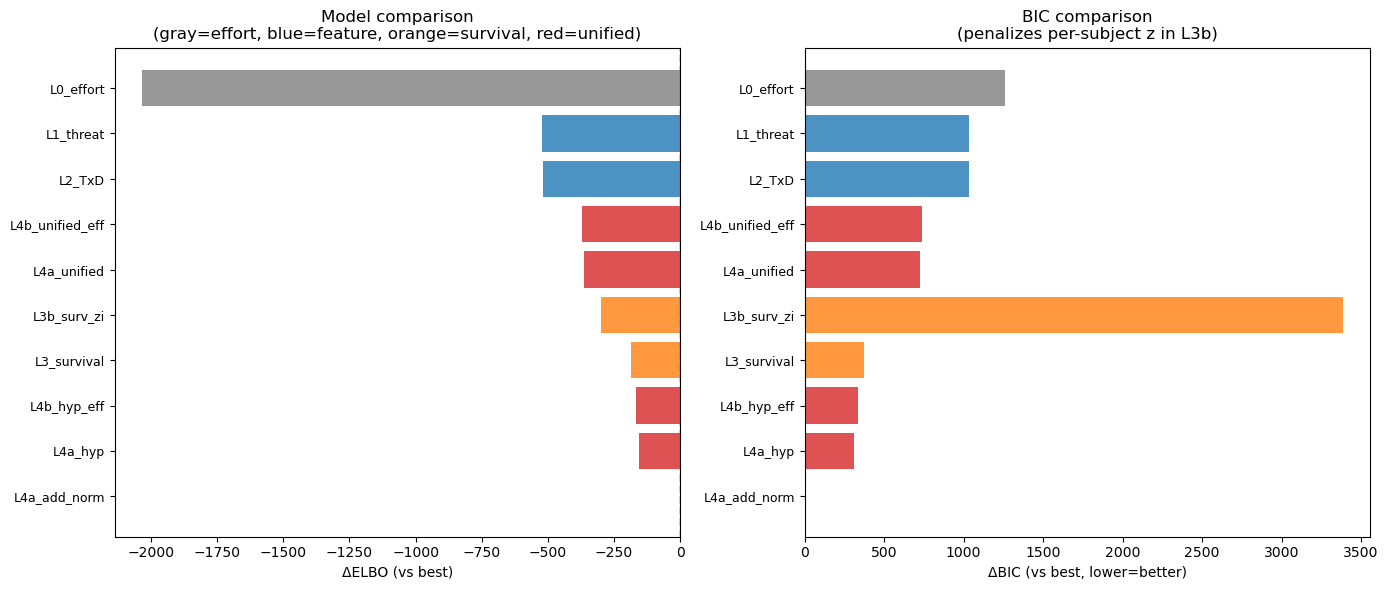

In [14]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ELBO bar chart
ax = axes[0]
colors = []
for m in comp['model']:
    if '4' in m: colors.append('#d62728')      # unified = red
    elif '3' in m: colors.append('#ff7f0e')     # survival = orange
    elif '0' in m: colors.append('#7f7f7f')     # effort only = gray
    else: colors.append('#1f77b4')               # feature = blue

ax.barh(range(len(comp)), comp['dELBO'], color=colors, alpha=0.8)
ax.set_yticks(range(len(comp)))
ax.set_yticklabels(comp['model'], fontsize=9)
ax.set_xlabel('ΔELBO (vs best)')
ax.set_title('Model comparison\n(gray=effort, blue=feature, orange=survival, red=unified)')
ax.axvline(0, ls='--', color='gray', alpha=0.3)

# BIC bar chart
ax = axes[1]
ax.barh(range(len(comp)), comp['dBIC'], color=colors, alpha=0.8)
ax.set_yticks(range(len(comp)))
ax.set_yticklabels(comp['model'], fontsize=9)
ax.set_xlabel('ΔBIC (vs best, lower=better)')
ax.set_title('BIC comparison\n(penalizes per-subject z in L3b)')
ax.axvline(0, ls='--', color='gray', alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'model_comparison_levels.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Extract parameters from best model

In [15]:
# Pick best unified model (by BIC among unified variants)
unified_names = [m for m in comp['model'] if '4' in m]
best_unified = comp[comp['model'].isin(unified_names)].sort_values('BIC').iloc[0]['model']
# Also get overall best
best_overall = comp.loc[comp['BIC'].idxmin(), 'model']

print(f'Best unified: {best_unified}')
print(f'Best overall: {best_overall}')

# Extract from best unified
r = results[best_unified]
predictive = Predictive(r['guide'], params=r['params'], num_samples=500)
samples = predictive(random.PRNGKey(99), **data)

print(f'\n=== {best_unified} population parameters ===')
for p in ['tau', 'lam', 'z', 'gamma', 'mu_logk', 'sd_logk', 'mu_logb', 'sd_logb']:
    if p in samples:
        v = np.array(samples[p])
        print(f'  {p:12s}: {v.mean():.3f} ± {v.std():.3f}')

# Per-subject params
logk = np.array(samples['logk'])
logb = np.array(samples['logb'])
k_est = np.exp(logk.mean(axis=0))
beta_est = np.exp(logb.mean(axis=0))
alpha_est = vigor_params.set_index('subj').loc[subj_ids, 'alpha_bayes'].values

print(f'\n=== Per-subject parameters ===')
for arr, lab in [(k_est,'k'), (beta_est,'β'), (alpha_est,'α')]:
    print(f'  {lab}: mean={arr.mean():.3f}, sd={arr.std():.3f}, range=[{arr.min():.3f}, {arr.max():.3f}]')

# Correlations
print(f'\n=== Parameter correlations ===')
for (a,la), (b,lb) in [((k_est,'k'),(alpha_est,'α')), ((k_est,'k'),(beta_est,'β')), ((beta_est,'β'),(alpha_est,'α'))]:
    r_val, p_val = stats.pearsonr(a, b)
    sig = ' *' if p_val < 0.05 else ''
    print(f'  {la}-{lb}: r={r_val:+.3f}, p={p_val:.4f}{sig}')

Best unified: L4a_add_norm
Best overall: L4a_add_norm

=== L4a_add_norm population parameters ===
  tau         : 0.759 ± 0.014
  lam         : 27.240 ± 1.121
  mu_logk     : 1.443 ± 0.052
  sd_logk     : 0.880 ± 0.034
  mu_logb     : 4.053 ± 0.046
  sd_logb     : 0.781 ± 0.033

=== Per-subject parameters ===
  k: mean=6.120, sd=6.300, range=[0.619, 41.038]
  β: mean=66.261, sd=39.361, range=[14.951, 223.319]
  α: mean=0.519, sd=0.193, range=[0.044, 0.918]

=== Parameter correlations ===
  k-α: r=-0.076, p=0.1938
  k-β: r=-0.111, p=0.0567
  β-α: r=+0.137, p=0.0186 *


In [16]:
# Save
comp.to_csv(STAT_DIR / 'unified_model_comparison.csv', index=False)
param_df = pd.DataFrame({'subj': subj_ids, 'k': k_est, 'beta': beta_est, 'alpha': alpha_est})
param_df.to_csv(STAT_DIR / 'unified_3param_clean.csv', index=False)
print(f'Saved: unified_model_comparison.csv, unified_3param_clean.csv')

Saved: unified_model_comparison.csv, unified_3param_clean.csv
